The data file is modified based on llc4320

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle # used to shade land cells
from MITgcmutils import diagnostics      # used to read in statistical diagnostics output
from MITgcmutils import mds
import cmocean                           # uses cmocean colormaps https://matplotlib.org/cmocean/

In [2]:
# path of the output files
path_scratch = '/scratch/z/zhansu/jczhang'
path_MITgcm = '/MITgcm_/MITgcm/verification'
path = '/tutorial_reentrant_channel/run/'

XC = mds.rdmds(path_scratch + path_MITgcm + path + 'XC')
YC = mds.rdmds(path_scratch + path_MITgcm + path + 'YC')
XG = mds.rdmds(path_scratch + path_MITgcm + path + 'XG')
YG = mds.rdmds(path_scratch + path_MITgcm + path + 'YG')
RC = mds.rdmds(path_scratch + path_MITgcm + path + 'RC')
RF = mds.rdmds(path_scratch + path_MITgcm + path + 'RF')
DXC = mds.rdmds(path_scratch + path_MITgcm + path + 'DXC')
DYC = mds.rdmds(path_scratch + path_MITgcm + path + 'DYC')
DXG = mds.rdmds(path_scratch + path_MITgcm + path + 'DXG')
DYG = mds.rdmds(path_scratch + path_MITgcm + path + 'DYG')
DRF = mds.rdmds(path_scratch + path_MITgcm + path + 'DRF')
DRC = mds.rdmds(path_scratch + path_MITgcm + path + 'DRC')
RAC = mds.rdmds(path_scratch + path_MITgcm + path + 'RAC')
hFacC = mds.rdmds(path_scratch + path_MITgcm + path + 'hFacC')
hFacW = mds.rdmds(path_scratch + path_MITgcm + path + 'hFacW')
hFacS = mds.rdmds(path_scratch + path_MITgcm + path + 'hFacS')

# create Nx+1,Ny+1 sized x,y vectors that include the eastern and northern
# domain edge locations respectively
Xp1 = np.append(XG[0,:], XG[0,-1] + DXG[0,-1])
Yp1 = np.append(YG[:,0], YG[-1,0] + DYG[-1,0])

# as specified in data.layers configuration
layer_bounds = np.array([-2.00, -1.75, -1.50, -1.25,
                         -1.00, -0.75, -0.50, -0.25,
                          0.00,  0.25,  0.50,  0.75,
                          1.00,  1.25,  1.50,  1.75,
                          2.00,  2.25,  2.50,  2.75,
                          3.00,  3.25,  3.50,  3.75,
                          4.00,  4.25,  4.50,   5.0,
                          5.5,    6.0,   6.5,   7.0,
                          7.5,    8.0,   8.5,   9.0,
                          9.5,   10.0,])

# extract overall MITgcm domain dimensions
Ny = XC.shape[0]
Nx = XC.shape[1]
Nr = RC.size
Nr_layers = layer_bounds.size - 1

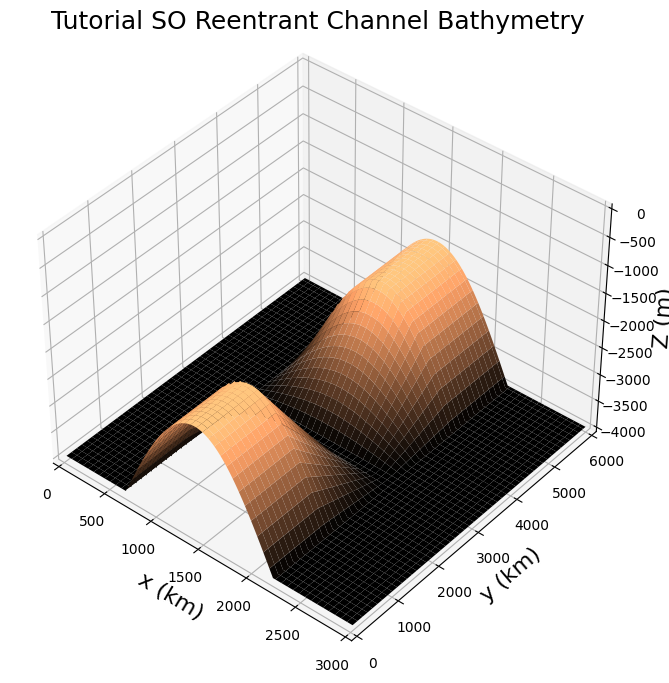

In [3]:
#plot bathymetry as 3D surface plot, as shown in fig 4.10

bathy = np.fromfile('./' + 'bathy.5km.bin', dtype='>f4')
bathy.shape = (Ny,Nx)
plt.figure(figsize=(10,8)) 
ax = plt.axes(projection='3d')
ax.plot_surface(XC[10:,:]/1000, YC[10:,:]/1000, bathy[10:,:], cmap='copper', edgecolor='none');
ax.view_init(40, -50)
ax.set_zlim(-4000,0)
ax.set_zlabel('Z (m)', fontsize=16)
ax.set_title('Tutorial SO Reentrant Channel Bathymetry', fontsize=18)
plt.xlabel('x (km)',fontsize=16); plt.ylabel('y (km)', fontsize=16)
plt.xlim(0,3000)
plt.ylim(0,6000);

In [5]:
# path of the output files
path_scratch = '/scratch/z/zhansu/jczhang'
path_MITgcm = '/MITgcm_/MITgcm//verification'
path = '/tutorial_reentrant_channel/run/'

nStep1 = 155520
nStep2 = 1421712


U1 = mds.rdmds('./'  +'U', nStep1)
V1 = mds.rdmds('./'  +'V', nStep1)
T1 = mds.rdmds('./'  +'T', nStep1)
S1 = mds.rdmds('./'  +'S', nStep1)
U2 = mds.rdmds('./'  +'U', nStep2)
V2 = mds.rdmds('./'  +'V', nStep2)
S2 = mds.rdmds('./'  +'S', nStep2)
T2 = mds.rdmds('./'  +'T', nStep2)


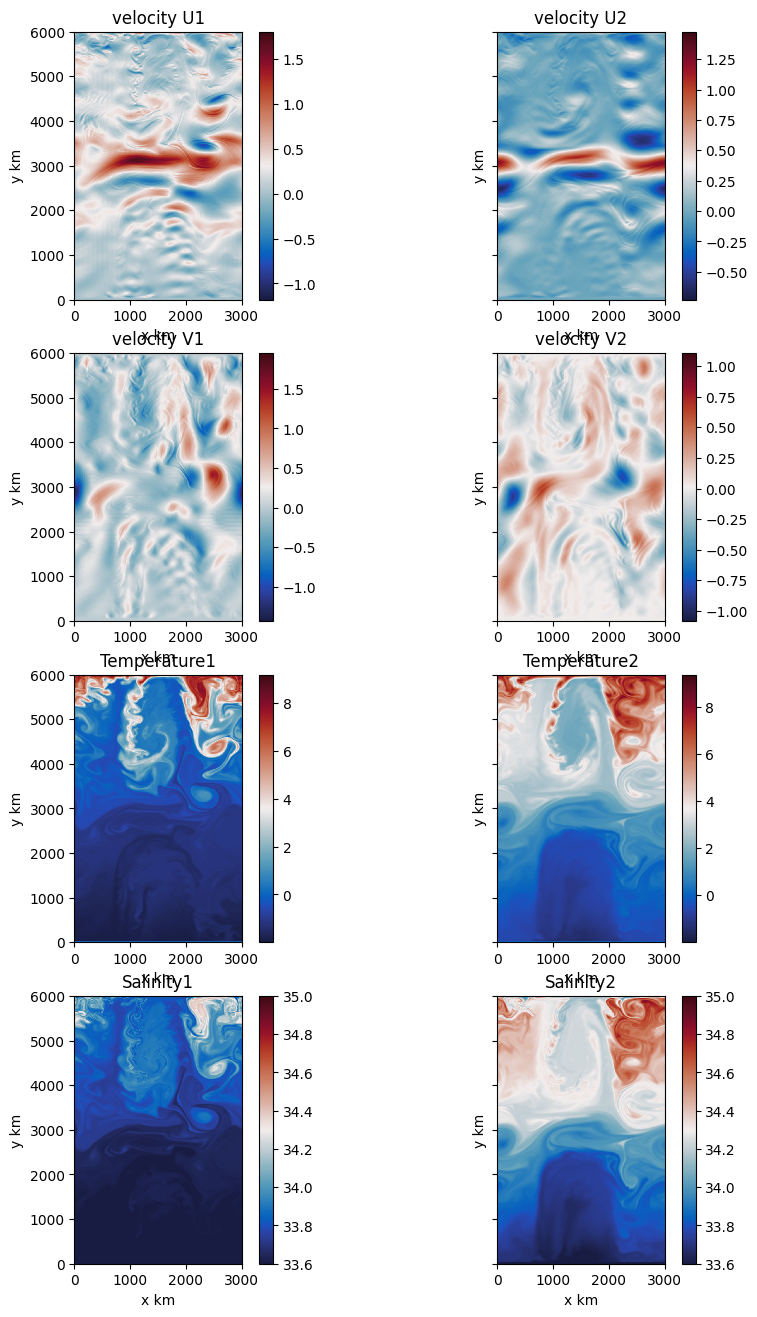

In [6]:
# plot
fig, axs = plt.subplots(4,2 , figsize=(10, 16), sharey=True)

ax = axs[0,0]
c = ax.pcolor(XC/1000, YC/1000, U1[0,:,:], vmin=np.nanmin(U1),vmax=np.nanmax(U1), cmap=cmocean.cm.balance)  
fig.colorbar(c, ax=ax)
ax.set_xlabel("x km")
ax.set_ylabel("y km")
ax.set_title("velocity U1")
ax.set_aspect(0.8)

ax = axs[1,0]
c = ax.pcolor(XC/1000, YC/1000, V1[10,:,:], vmin=np.nanmin(V1),vmax=np.nanmax(V1), cmap=cmocean.cm.balance)
fig.colorbar(c, ax=ax)
ax.set_xlabel("x km")
ax.set_ylabel("y km")
ax.set_title("velocity V1")
ax.set_aspect(0.8)

ax = axs[0,1]
c = ax.pcolor(XC/1000, YC/1000, U2[10,:,:], vmin=np.nanmin(U2),vmax=np.nanmax(U2), cmap=cmocean.cm.balance)
fig.colorbar(c, ax=ax)
ax.set_xlabel("x km")
ax.set_ylabel("y km")
ax.set_title("velocity U2")
ax.set_aspect(0.8)

ax = axs[1,1]
c = ax.pcolor(XC/1000, YC/1000, V2[10,:,:], vmin=np.nanmin(V2),vmax=np.nanmax(V2),cmap=cmocean.cm.balance)
fig.colorbar(c, ax=ax)
ax.set_xlabel("x km")
ax.set_ylabel("y km")
ax.set_title("velocity V2")
ax.set_aspect(0.8)

ax = axs[2,0]
c = ax.pcolor(XC/1000, YC/1000, T1[10,:,:], vmin=np.nanmin(T1),vmax=np.nanmax(T1), cmap=cmocean.cm.balance)
fig.colorbar(c, ax=ax)
ax.set_xlabel("x km")
ax.set_ylabel("y km")
ax.set_title("Temperature1")
ax.set_aspect(0.8)

ax = axs[2,1]
c = ax.pcolor(XC/1000, YC/1000, T2[10,:,:], vmin=np.nanmin(T2),vmax=np.nanmax(T2),cmap=cmocean.cm.balance)
fig.colorbar(c, ax=ax)
ax.set_xlabel("x km")
ax.set_ylabel("y km")
ax.set_title("Temperature2")
ax.set_aspect(0.8)

ax = axs[3,0]
c = ax.pcolor(XC/1000, YC/1000, S1[10,:,:], vmin=33.6,vmax=35, cmap=cmocean.cm.balance)
fig.colorbar(c, ax=ax)
ax.set_xlabel("x km")
ax.set_ylabel("y km")
ax.set_title("Salinity1")
ax.set_aspect(0.8)

ax = axs[3,1]
c = ax.pcolor(XC/1000, YC/1000, S2[10,:,:], vmin=33.6,vmax=35,cmap=cmocean.cm.balance)
fig.colorbar(c, ax=ax)
ax.set_xlabel("x km")
ax.set_ylabel("y km")
ax.set_title("Salinity2")
ax.set_aspect(0.8)

In [12]:
time_index = np.linspace(1399680, 1413504, 33).astype('int')
# time_index = 4533200
path_images = './02_images/'
path_images_T = 'potential_temperature/'
path_images_Eta = 'Eta/'

for i in range(len(time_index)):
    # data = mds.rdmds(path_scratch + path_MITgcm + path +'Eta', time_index[i])
    # plt.pcolor(XC/1000, YC/1000, data[:,:], vmin = np.nanmin(data[:,:]), vmax = np.nanmax(data[:,:]), cmap=cmocean.cm.balance)
    # plt.title("potential_temperature - 5km - Hydro")
    U = mds.rdmds(path_scratch + path_MITgcm + path +'U', time_index[i])
    V = mds.rdmds(path_scratch + path_MITgcm + path +'V', time_index[i])
    u = np.sqrt(U**2 + V**2)
    plt.pcolor(XC/1000, YC/1000, u[0,:,:], cmap=cmocean.cm.balance)
    plt.title("Surface horizontal velocity - 5km - Hydro")
    plt.xlabel('x deg')
    plt.ylabel('y deg') 
    plt.colorbar()
    plt.savefig(path_images + path_images_Eta + f'{time_index[i]:010}' +'.png')
    plt.close()

# U = mds.rdmds(path_scratch + path_MITgcm + path +'U', time_index)
# V = mds.rdmds(path_scratch + path_MITgcm + path +'V', time_index)
# u = np.sqrt(U**2 + V**2)
# plt.pcolor(XC/1000, YC/1000, u[0,:,:], vmin =0, vmax = 0.75, cmap=cmocean.cm.balance)
# plt.title("Surface horizontal velocity - 5km - Hydro")
# plt.xlabel('x deg')
# plt.ylabel('y deg') 
# plt.colorbar()
# plt.savefig(path_images + f'{time_index:010}' +'.png')
# plt.close()

In [9]:
time_index = np.linspace(1399680, 1413504, 33).astype('int')
print(time_index)

[1399680 1400112 1400544 1400976 1401408 1401840 1402272 1402704 1403136
 1403568 1404000 1404432 1404864 1405296 1405728 1406160 1406592 1407024
 1407456 1407888 1408320 1408752 1409184 1409616 1410048 1410480 1410912
 1411344 1411776 1412208 1412640 1413072 1413504]
